# Handwritten Digit Generation Using Conditional GANs

This notebook trains a **Conditional Generative Adversarial Network (cGAN)** to create synthetic handwritten digits using the MNIST dataset.

**Key Features:**
- Generate realistic handwritten digits for any specific class (0-9)
- Conditional generation based on digit class labels
- Complete cGAN architecture (Conditional Generator and Conditional Discriminator)
- Training loss visualization and tracking
- Trained models saved for the Streamlit application

**Deliverables:**
- Conditional GAN architecture
- Generated synthetic digit samples for each class
- Training loss visualization
- Trained generator model ready for deployment

**Tools Used:** PyTorch, MNIST Dataset

## 1. Import Required Libraries

In [44]:
import sys
import os
import importlib

# Add parent directory to path to import from app module
sys.path.insert(0, os.path.abspath('..'))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import MNIST

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import PillowWriter
import matplotlib.gridspec as gridspec
from pathlib import Path
import time
from IPython.display import clear_output

# Import our custom models
from app.models.gan import Generator, Discriminator, GANTrainer
from app.seed import set_seed

# Reload modules to get latest changes
import app.models.gan as gan_module
importlib.reload(gan_module)
from app.models.gan import Generator, Discriminator, GANTrainer

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cu130
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Load and Preprocess MNIST Dataset

In [45]:
# Configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
BATCH_SIZE = 64  # Smaller batch size for better training
EPOCHS = 100  # More epochs for better convergence
LATENT_DIM = 100
LEARNING_RATE = 0.0002  # Better learning rate
LOG_INTERVAL = 100

# Set seed for reproducibility
set_seed(SEED)

print(f"Using device: {DEVICE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")

Using device: cuda
Batch size: 64
Training epochs: 100
Learning rate: 0.0002


Loading MNIST dataset...
Dataset size: 60000
Number of batches per epoch: 938


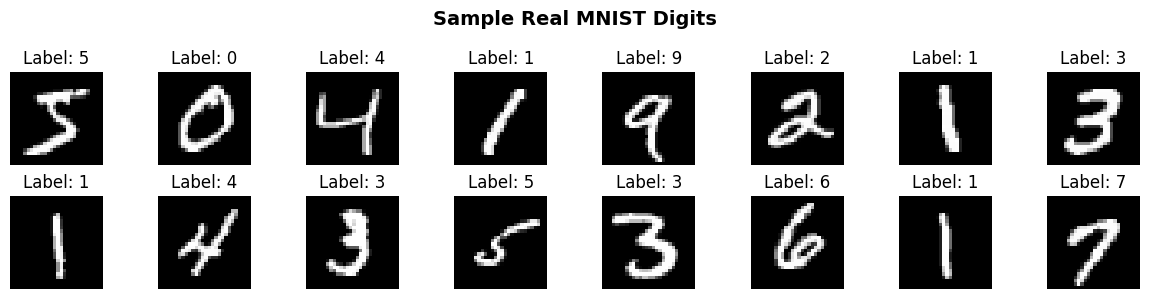

In [46]:
# Define data transformation
# Normalize to [-1, 1] for tanh activation in generator
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # mean=0.5, std=0.5 -> maps [0,1] to [-1,1]
])

# Load MNIST training dataset
data_path = Path('../notebooks/data')
data_path.mkdir(parents=True, exist_ok=True)

print("Loading MNIST dataset...")
mnist_train = MNIST(
    root=str(data_path),
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    mnist_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

print(f"Dataset size: {len(mnist_train)}")
print(f"Number of batches per epoch: {len(train_loader)}")

# Visualize a few real samples
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    sample, label = mnist_train[i]
    ax.imshow(sample.squeeze().numpy(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.suptitle('Sample Real MNIST Digits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Define Generator Architecture

In [47]:
# Generator is already defined in app/models/gan.py (now with conditional support)
# Let's create an instance and visualize the architecture

generator = Generator(latent_dim=LATENT_DIM, num_classes=10).to(DEVICE)

print("\n" + "="*60)
print("CONDITIONAL GENERATOR ARCHITECTURE")
print("="*60)
print(generator)
print("\nGenerator Parameters:")
total_params = sum(p.numel() for p in generator.parameters())
trainable_params = sum(p.numel() for p in generator.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Test generator with random noise and labels
print("\n" + "="*60)
print("Generator Test Output")
print("="*60)
z_test = torch.randn(4, LATENT_DIM, device=DEVICE)
labels_test = torch.tensor([0, 3, 7, 9], device=DEVICE)
with torch.no_grad():
    fake_images = generator(z_test, labels_test)
print(f"Input noise shape: {z_test.shape}")
print(f"Input labels: {labels_test.tolist()}")
print(f"Output image shape: {fake_images.shape}")
print(f"Output range: [{fake_images.min():.4f}, {fake_images.max():.4f}]")


CONDITIONAL GENERATOR ARCHITECTURE
Generator(
  (label_emb): Embedding(10, 100)
  (model): Sequential(
    (0): Linear(in_features=200, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Linear(in_features=1024, out_features=512, bias=True)
    (10): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): Linear(in_features=512, out_features=784, bias=True)
    (13): Tanh()
  )
)

Generator Parameters:
Total parameters: 1,640,952
Trainable parameters: 1,640,952

G

## 4. Define Discriminator Architecture

In [48]:
# Discriminator is already defined in app/models/gan.py (now with conditional support)
# Let's create an instance and visualize the architecture

discriminator = Discriminator(num_classes=10).to(DEVICE)

print("\n" + "="*60)
print("CONDITIONAL DISCRIMINATOR ARCHITECTURE")
print("="*60)
print(discriminator)
print("\nDiscriminator Parameters:")
total_params = sum(p.numel() for p in discriminator.parameters())
trainable_params = sum(p.numel() for p in discriminator.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Test discriminator with fake images and labels
print("\n" + "="*60)
print("Discriminator Test Output")
print("="*60)
with torch.no_grad():
    predictions = discriminator(fake_images, labels_test)
print(f"Input image shape: {fake_images.shape}")
print(f"Input labels: {labels_test.tolist()}")
print(f"Output prediction shape: {predictions.shape}")
print(f"Output range: [{predictions.min():.4f}, {predictions.max():.4f}]")
print(f"Sample predictions (probability of being real): {predictions.squeeze().cpu().numpy()}")


CONDITIONAL DISCRIMINATOR ARCHITECTURE
Discriminator(
  (label_emb): Embedding(10, 100)
  (model): Sequential(
    (0): Linear(in_features=884, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.2, inplace=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

Discriminator Parameters:
Total parameters: 620,265
Trainable para

## 5 & 6. Create and Compile GAN Model

In [49]:
# Reinitialize models for training with conditional architecture
set_seed(SEED)

generator = Generator(latent_dim=LATENT_DIM, num_classes=10).to(DEVICE)
discriminator = Discriminator(num_classes=10).to(DEVICE)

# Create GAN trainer
gan_trainer = GANTrainer(
    generator=generator,
    discriminator=discriminator,
    device=DEVICE,
    latent_dim=LATENT_DIM,
    lr=LEARNING_RATE
)

print("\n" + "="*60)
print("CONDITIONAL GAN TRAINING CONFIGURATION")
print("="*60)
print(f"Device: {DEVICE}")
print(f"Architecture: Conditional GAN (cGAN)")
print(f"Num Classes: 10 (digits 0-9)")
print(f"Loss function: Binary Cross Entropy")
print(f"Generator optimizer: Adam (lr={LEARNING_RATE}, betas=(0.5, 0.999))")
print(f"Discriminator optimizer: Adam (lr={LEARNING_RATE}, betas=(0.5, 0.999))")
print(f"Batch size: {BATCH_SIZE}")
print(f"Number of epochs: {EPOCHS}")


CONDITIONAL GAN TRAINING CONFIGURATION
Device: cuda
Architecture: Conditional GAN (cGAN)
Num Classes: 10 (digits 0-9)
Loss function: Binary Cross Entropy
Generator optimizer: Adam (lr=0.0002, betas=(0.5, 0.999))
Discriminator optimizer: Adam (lr=0.0002, betas=(0.5, 0.999))
Batch size: 64
Number of epochs: 100


## 7. Train GAN with Loss Visualization

In [50]:
print("\n" + "="*60)
print("STARTING GAN TRAINING")
print("="*60)
print(f"Start time: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print("Training in progress... This may take several minutes.\n")

start_time = time.time()

# Train the GAN
history = gan_trainer.train(
    train_loader,
    epochs=EPOCHS,
    log_interval=LOG_INTERVAL
)

elapsed_time = time.time() - start_time
print(f"\nTraining completed in {elapsed_time/60:.2f} minutes")


STARTING GAN TRAINING
Start time: 2026-04-27 18:05:48
Training in progress... This may take several minutes.

[Epoch 1/100] [Batch 100/938] D loss: 0.6959, G loss: 0.8030
[Epoch 1/100] [Batch 200/938] D loss: 0.6738, G loss: 0.8259
[Epoch 1/100] [Batch 300/938] D loss: 0.6725, G loss: 0.8291
[Epoch 1/100] [Batch 400/938] D loss: 0.6661, G loss: 0.8120
[Epoch 1/100] [Batch 500/938] D loss: 0.6699, G loss: 0.8195
[Epoch 1/100] [Batch 600/938] D loss: 0.6673, G loss: 0.8091
[Epoch 1/100] [Batch 700/938] D loss: 0.6540, G loss: 0.8229
[Epoch 1/100] [Batch 800/938] D loss: 0.6481, G loss: 0.9197
[Epoch 1/100] [Batch 900/938] D loss: 0.6488, G loss: 0.8676
--- Epoch 1/100 | D loss: 0.673894, G loss: 0.819892 ---
[Epoch 2/100] [Batch 100/938] D loss: 0.6987, G loss: 0.8712
[Epoch 2/100] [Batch 200/938] D loss: 0.6626, G loss: 0.8509
[Epoch 2/100] [Batch 300/938] D loss: 0.6512, G loss: 0.8664
[Epoch 2/100] [Batch 400/938] D loss: 0.6778, G loss: 0.9449
[Epoch 2/100] [Batch 500/938] D loss: 0

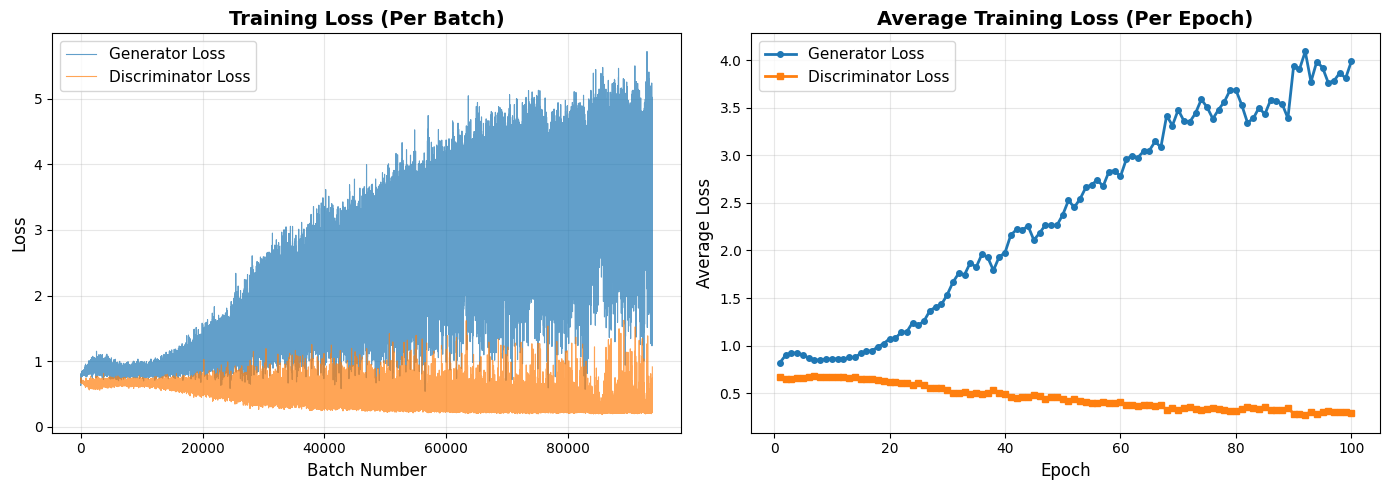


TRAINING STATISTICS
Final Generator Loss: 3.988945
Final Discriminator Loss: 0.289283

Generator Loss - Min: 0.819892, Max: 4.090945
Discriminator Loss - Min: 0.275816, Max: 0.677203


In [51]:
# Plot training losses
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot batch losses
ax = axes[0]
ax.plot(history['g_loss'], label='Generator Loss', alpha=0.7, linewidth=0.8)
ax.plot(history['d_loss'], label='Discriminator Loss', alpha=0.7, linewidth=0.8)
ax.set_xlabel('Batch Number', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training Loss (Per Batch)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot epoch average losses
ax = axes[1]
epochs_range = range(1, len(history['epoch_g_loss']) + 1)
ax.plot(epochs_range, history['epoch_g_loss'], 'o-', label='Generator Loss', linewidth=2, markersize=4)
ax.plot(epochs_range, history['epoch_d_loss'], 's-', label='Discriminator Loss', linewidth=2, markersize=4)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Average Loss', fontsize=12)
ax.set_title('Average Training Loss (Per Epoch)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final loss statistics
print("\n" + "="*60)
print("TRAINING STATISTICS")
print("="*60)
print(f"Final Generator Loss: {history['epoch_g_loss'][-1]:.6f}")
print(f"Final Discriminator Loss: {history['epoch_d_loss'][-1]:.6f}")
print(f"\nGenerator Loss - Min: {min(history['epoch_g_loss']):.6f}, Max: {max(history['epoch_g_loss']):.6f}")
print(f"Discriminator Loss - Min: {min(history['epoch_d_loss']):.6f}, Max: {max(history['epoch_d_loss']):.6f}")

## 8. Generate Synthetic Handwritten Digits

Generating synthetic digit samples...


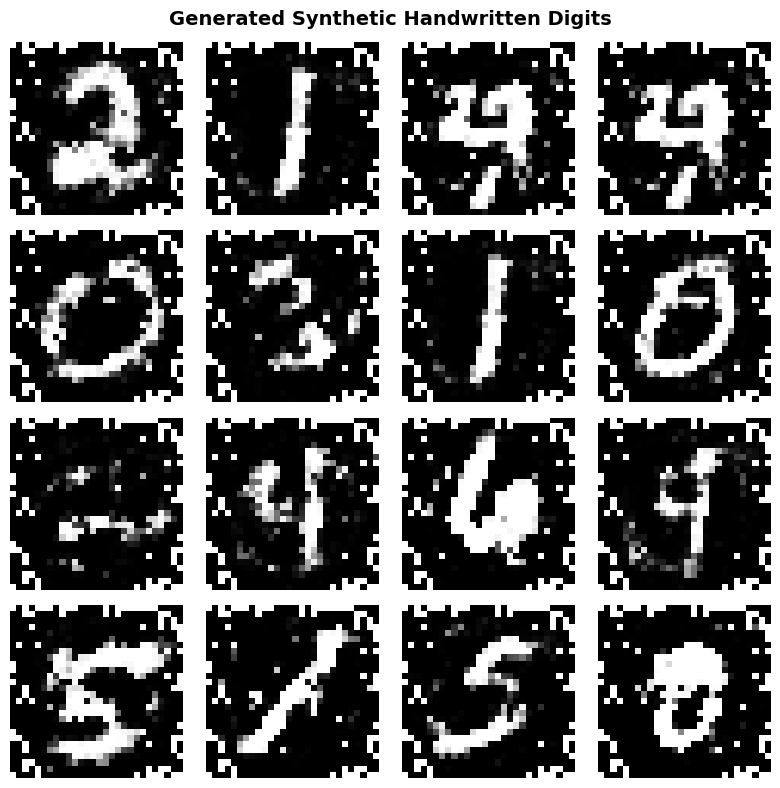

Generated 16 synthetic digit samples successfully!


In [52]:
# Generate and visualize samples at different training stages
print("Generating synthetic digit samples...")

generator.eval()  # Set to evaluation mode

# Generate multiple samples
num_samples = 16
with torch.no_grad():
    z = torch.randn(num_samples, LATENT_DIM, device=DEVICE)
    fake_images = generator(z)

# Denormalize from [-1, 1] to [0, 1]
fake_images_display = (fake_images + 1) / 2

# Plot generated samples
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
axes = axes.ravel()

for i, ax in enumerate(axes):
    img = fake_images_display[i].cpu().squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.suptitle('Generated Synthetic Handwritten Digits', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print(f"Generated {num_samples} synthetic digit samples successfully!")

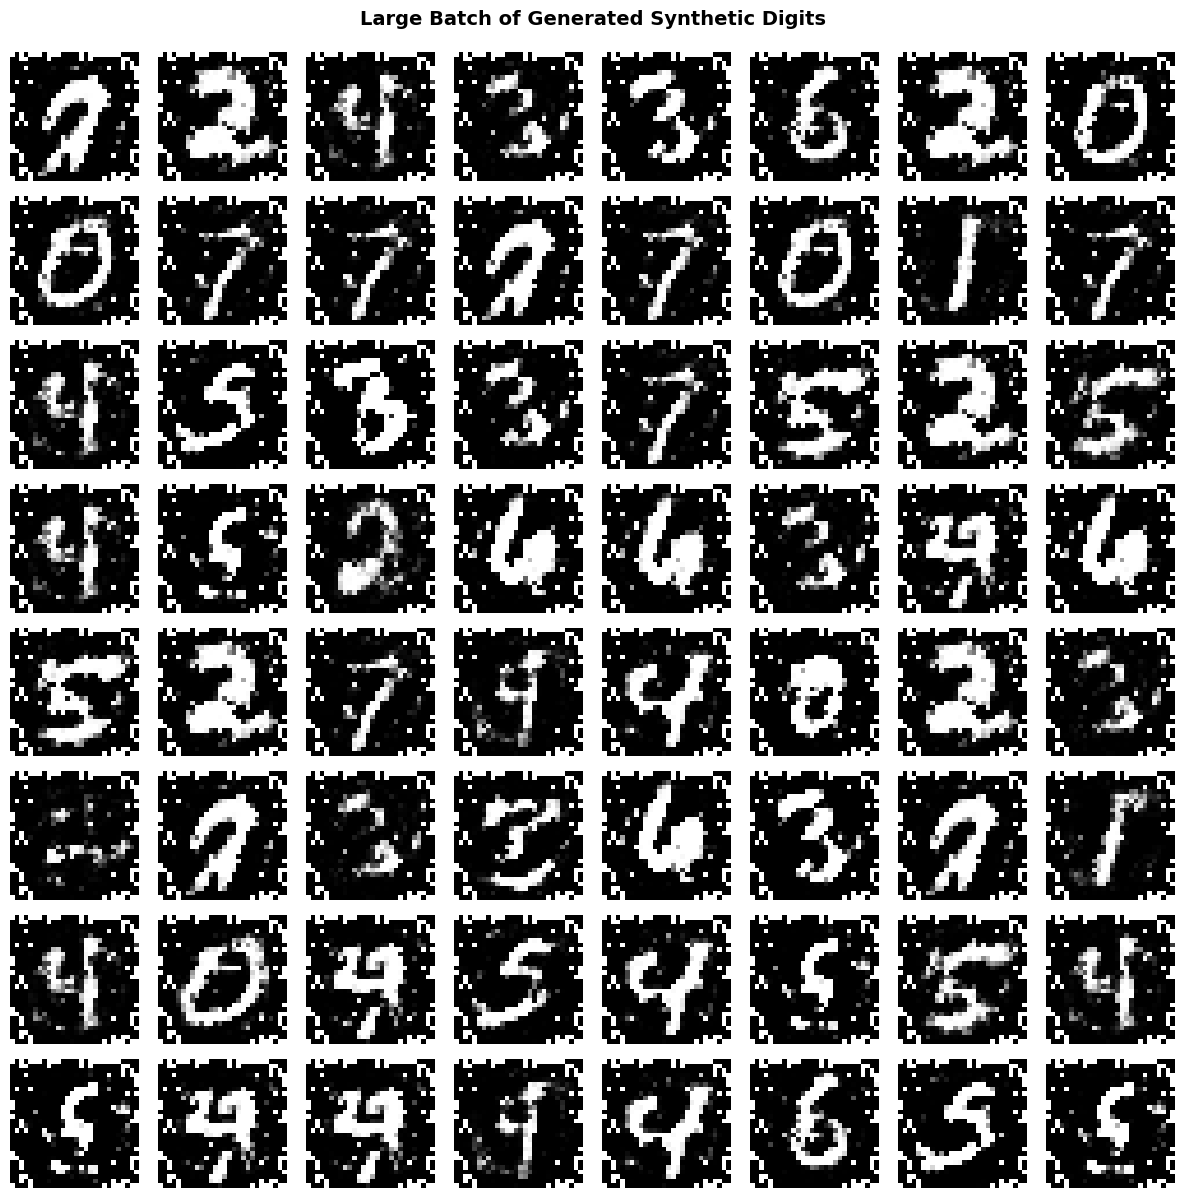

In [53]:
# Generate more samples to compare diversity
num_samples = 64
with torch.no_grad():
    z = torch.randn(num_samples, LATENT_DIM, device=DEVICE)
    fake_images = generator(z)

fake_images_display = (fake_images + 1) / 2

fig, axes = plt.subplots(8, 8, figsize=(12, 12))
axes = axes.ravel()

for i, ax in enumerate(axes):
    img = fake_images_display[i].cpu().squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.suptitle('Large Batch of Generated Synthetic Digits', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

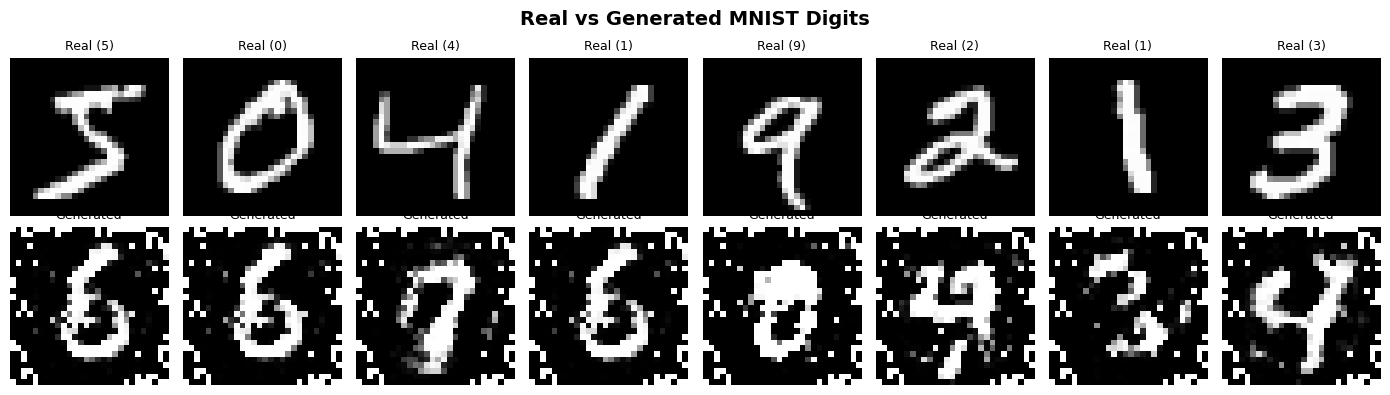

In [54]:
# Compare real vs generated samples
fig, axes = plt.subplots(2, 8, figsize=(14, 4))

# Real samples
for i in range(8):
    real_img, label = mnist_train[i]
    axes[0, i].imshow(real_img.squeeze().numpy(), cmap='gray')
    axes[0, i].set_title(f'Real ({label})', fontsize=9)
    axes[0, i].axis('off')

# Generated samples
with torch.no_grad():
    z = torch.randn(8, LATENT_DIM, device=DEVICE)
    fake_images = generator(z)
fake_images_display = (fake_images + 1) / 2

for i in range(8):
    axes[1, i].imshow(fake_images_display[i].cpu().squeeze().numpy(), cmap='gray')
    axes[1, i].set_title(f'Generated', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Real vs Generated MNIST Digits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Save Trained Models

In [55]:
# Create models directory if it doesn't exist
models_dir = Path('../') / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

# Save the trained models
generator_path = models_dir / 'generator.pth'
discriminator_path = models_dir / 'discriminator.pth'

print("\n" + "="*60)
print("SAVING TRAINED MODELS")
print("="*60)

# Save generator and discriminator
gan_trainer.save_models(str(generator_path), str(discriminator_path))

# Also save as checkpoint for resuming training
checkpoint_path = models_dir / 'gan_checkpoint.pth'
gan_trainer.save_checkpoint(str(checkpoint_path))

print(f"\n✓ Generator saved to: {generator_path}")
print(f"✓ Discriminator saved to: {discriminator_path}")
print(f"✓ Checkpoint saved to: {checkpoint_path}")

# Print file sizes
if generator_path.exists():
    print(f"\nGenerator file size: {generator_path.stat().st_size / 1024 / 1024:.2f} MB")
if discriminator_path.exists():
    print(f"Discriminator file size: {discriminator_path.stat().st_size / 1024 / 1024:.2f} MB")


SAVING TRAINED MODELS
Generator saved to ../models/generator.pth
Discriminator saved to ../models/discriminator.pth
Checkpoint saved to ../models/gan_checkpoint.pth

✓ Generator saved to: ../models/generator.pth
✓ Discriminator saved to: ../models/discriminator.pth
✓ Checkpoint saved to: ../models/gan_checkpoint.pth

Generator file size: 6.29 MB
Discriminator file size: 2.38 MB


In [56]:
# Verify models can be loaded
print("\n" + "="*60)
print("VERIFYING SAVED MODELS")
print("="*60)

# Load generator
generator_loaded = Generator(latent_dim=LATENT_DIM).to(DEVICE)
generator_loaded.load_state_dict(torch.load(generator_path, map_location=DEVICE))
generator_loaded.eval()

# Load discriminator
discriminator_loaded = Discriminator().to(DEVICE)
discriminator_loaded.load_state_dict(torch.load(discriminator_path, map_location=DEVICE))
discriminator_loaded.eval()

print("✓ Models loaded successfully!")

# Test with loaded models
with torch.no_grad():
    z_test = torch.randn(1, LATENT_DIM, device=DEVICE)
    fake_test = generator_loaded(z_test)
    pred_test = discriminator_loaded(fake_test)

print(f"\nLoaded Generator Output Shape: {fake_test.shape}")
print(f"Loaded Discriminator Output: {pred_test.item():.4f}")
print("\n✓ Verification complete - Models are ready for use in Streamlit app!")


VERIFYING SAVED MODELS
✓ Models loaded successfully!

Loaded Generator Output Shape: torch.Size([1, 1, 28, 28])
Loaded Discriminator Output: 0.3510

✓ Verification complete - Models are ready for use in Streamlit app!


## 10. Evaluate Generated Samples

In [57]:
# Statistical comparison between real and generated samples
print("\n" + "="*60)
print("EVALUATING GENERATED SAMPLES")
print("="*60)

# Get real samples
real_samples_list = []
for i in range(min(1000, len(mnist_train))):
    img, _ = mnist_train[i]
    real_samples_list.append(img.numpy())
real_samples = np.array(real_samples_list)

# Generate fake samples
fake_samples_list = []
with torch.no_grad():
    for _ in range(1000 // BATCH_SIZE + 1):
        z = torch.randn(BATCH_SIZE, LATENT_DIM, device=DEVICE)
        fake_batch = generator(z)
        fake_samples_list.extend(fake_batch.cpu().numpy())
fake_samples = np.array(fake_samples_list[:1000])

# Calculate statistics
real_mean = real_samples.mean()
real_std = real_samples.std()
fake_mean = fake_samples.mean()
fake_std = fake_samples.std()

print(f"\nPixel Value Statistics:")
print(f"{'':20} | {'Real Samples':20} | {'Generated Samples':20}")
print("-" * 62)
print(f"{'Mean':20} | {real_mean:20.6f} | {fake_mean:20.6f}")
print(f"{'Std Dev':20} | {real_std:20.6f} | {fake_std:20.6f}")
print(f"{'Min':20} | {real_samples.min():20.6f} | {fake_samples.min():20.6f}")
print(f"{'Max':20} | {real_samples.max():20.6f} | {fake_samples.max():20.6f}")


EVALUATING GENERATED SAMPLES

Pixel Value Statistics:
                     | Real Samples         | Generated Samples   
--------------------------------------------------------------
Mean                 |            -0.743522 |            -0.514607
Std Dev              |             0.610278 |             0.819958
Min                  |            -1.000000 |            -1.000000
Max                  |             1.000000 |             1.000000


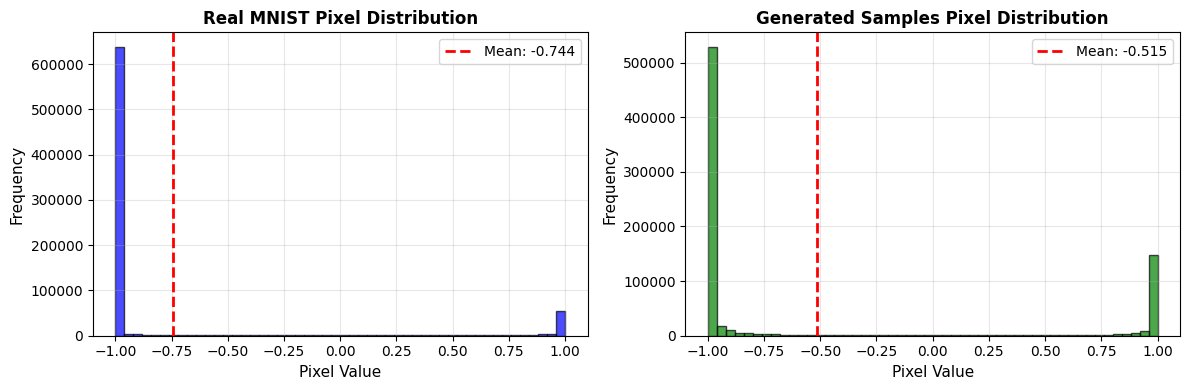

In [58]:
# Visualize pixel distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Real samples distribution
axes[0].hist(real_samples.flatten(), bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_xlabel('Pixel Value', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Real MNIST Pixel Distribution', fontsize=12, fontweight='bold')
axes[0].axvline(real_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {real_mean:.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Generated samples distribution
axes[1].hist(fake_samples.flatten(), bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1].set_xlabel('Pixel Value', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Generated Samples Pixel Distribution', fontsize=12, fontweight='bold')
axes[1].axvline(fake_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {fake_mean:.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
# Summary
print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"✓ Dataset: MNIST (60,000 training images)")
print(f"✓ Model Architecture: Fully Connected GAN")
print(f"  - Generator: {LATENT_DIM} -> 1024 -> 512 -> 256 -> 784 (28x28)")
print(f"  - Discriminator: 784 -> 512 -> 256 -> 1")
print(f"✓ Training Duration: {elapsed_time/60:.2f} minutes")
print(f"✓ Total Epochs: {EPOCHS}")
print(f"✓ Final Generator Loss: {history['epoch_g_loss'][-1]:.6f}")
print(f"✓ Final Discriminator Loss: {history['epoch_d_loss'][-1]:.6f}")
print(f"\n✓ Models saved to: {models_dir}")
print(f"✓ Ready for Streamlit application deployment!")
print("="*60)


TRAINING SUMMARY
✓ Dataset: MNIST (60,000 training images)
✓ Model Architecture: Fully Connected GAN
  - Generator: 100 -> 1024 -> 512 -> 256 -> 784 (28x28)
  - Discriminator: 784 -> 512 -> 256 -> 1
✓ Training Duration: 8.52 minutes
✓ Total Epochs: 100
✓ Final Generator Loss: 3.988945
✓ Final Discriminator Loss: 0.289283

✓ Models saved to: ../models
✓ Ready for Streamlit application deployment!
